# Predicción de Precios de Vehículos Usados (Core)
Implementar y evaluar modelos de regresión, y seleccionar el mejor modelo basado en las métricas de evaluación.



> Requisitos

 1. Carga y Exploración de Datos:

- Descargar y cargar el dataset.
- Realizar una exploración inicial para entender la estructura del dataset.
- Identificar valores faltantes, duplicados y outliers.

 2. Limpieza y Preprocesamiento:

Manejar valores faltantes.

- Eliminar duplicados.
- Corregir inconsistencias en los datos categóricos.
- Escalar las características numéricas.
- Realizar transformaciones necesarias para las características categóricas.

 3. Exploración de Datos:

- Crear visualizaciones univariadas y multivariadas.
- Calcular estadísticas descriptivas.

 4. Modelado y Evaluación:

- Implementar al menos dos modelos de regresión (Linear Regression y Random Forest Regressor).
- Evaluar los modelos utilizando MSE, RMSE, y R^2.
- Seleccionar el mejor modelo basado en las métricas de evaluación.

 5. Optimización del Modelo:

- Optimizar el modelo seleccionado utilizando GridSearchCV.

 6. Documentación y Entrega:

- Documentar todo el proceso en un archivo .ipynb claramente comentado.
- Crear visualizaciones con interpretaciones.
- Subir el archivo a un repositorio en GitHub con un tag de liberación.


#Resumen Ejecutivo para la Automotora

El presente análisis tuvo como objetivo desarrollar un modelo de Machine Learning capaz de estimar el precio de venta de vehículos usados a partir de sus características técnicas y comerciales, utilizando información histórica de miles de automóviles publicados en el mercado.

Para ello, se analizaron variables como año de fabricación, kilometraje, marca, modelo, transmisión, tipo de combustible, condición del vehículo y otras características relevantes que influyen en el valor de mercado. Posteriormente, se aplicaron técnicas de limpieza y preparación de datos para asegurar que la información utilizada fuera consistente, representativa y libre de valores extremos poco realistas.

Se evaluaron distintos modelos predictivos, incluyendo Regresión Lineal, Ridge Regression y Random Forest. Tras comparar su desempeño mediante métricas estadísticas especializadas, el modelo Random Forest Regressor obtuvo los mejores resultados, alcanzando un coeficiente de determinación (R²) cercano a 0,81, lo que significa que es capaz de explicar aproximadamente el 81% de la variación observada en los precios de los vehículos.

Adicionalmente, el análisis de importancia de variables mostró que el año de fabricación y el kilometraje son los principales factores que determinan el precio de un vehículo usado, concentrando gran parte de la capacidad predictiva del modelo. Este resultado coincide con los criterios habitualmente utilizados por el mercado automotriz para valorar vehículos, lo que aporta confianza adicional sobre la lógica empleada por el sistema para realizar sus estimaciones.

Desde una perspectiva de negocio, esto permite estimar precios de venta de manera más objetiva y basada en datos, reduciendo la dependencia exclusiva de criterios subjetivos o de la experiencia individual. El modelo puede utilizarse como una herramienta de apoyo para:

1. Definir precios de publicación más competitivos.

2. Detectar vehículos potencialmente sobrevalorados o subvalorados.

3. Estandarizar criterios de tasación dentro de la automotora.

4. Apoyar decisiones de compra de vehículos para reventa.

5. Mejorar la velocidad y la consistencia del proceso de valoración.

En términos prácticos, el sistema aprende de miles de transacciones y de las características de vehículos similares para entregar una estimación razonable del precio esperado de mercado. Esto permite a la automotora tomar decisiones más informadas, mejorar su competitividad y reducir el riesgo asociado a errores de valorización.

Finalmente, los resultados obtenidos demuestran que el uso de técnicas de Ciencia de Datos y Machine Learning constituye una herramienta efectiva para apoyar la gestión comercial y la toma de decisiones dentro del negocio automotriz.



> Uso de herramientas de apoyo

Para el desarrollo de este trabajo se utilizaron herramientas de apoyo basadas en inteligencia artificial generativa y material entregado en clases, con el objetivo de complementar la revisión teórica, obtener sugerencias de código y mejorar la redacción de algunos apartados. Estas herramientas se usaron únicamente como soporte y no sustituyen el criterio propio ni el trabajo analítico realizado.

> Uso de recursos externos (Kaggle y material público)

Además del material oficial del curso, se revisaron algunos notebooks y discusiones públicas en la plataforma Kaggle relacionados con problemas similares de predicción de precios de vehículos, con el objetivo de contrastar enfoques, validar ideas y mejorar la interpretación de resultados. Estos recursos se utilizaron únicamente como referencia conceptual y no se copiaron soluciones completas; el código final, las decisiones metodológicas y las conclusiones presentadas en este proyecto fueron desarrollados y adaptados de forma independiente por el autor.
datos
+1

> Responsabilidad de las conclusiones

Todas las decisiones metodológicas (selección de variables, elección y ajuste de modelos, criterios de evaluación) y las conclusiones presentadas en este informe son de exclusiva responsabilidad del autor. Cualquier interpretación de resultados o propuesta de uso del modelo en contexto empresarial refleja el juicio personal a partir del material del curso y del análisis efectuado.

In [1]:
# ============================================================
# PARTE A — EXPLORACIÓN INICIAL Y LIMPIEZA
# Predicción de precios de vehículos usados
# ============================================================

# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Ruta del dataset en Drive
ruta = '/content/drive/MyDrive/vehicles.csv'

# Como el archivo es grande, primero cargamos una muestra inicial
df = pd.read_csv(ruta, nrows=100000)

# Tamaño inicial de la muestra
print(f'Tamaño del dataset cargado: {df.shape}')

Tamaño del dataset cargado: (100000, 26)


In [4]:
# Muestra inicial
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


# Interpretación de la muestra inicial

- Al observar las primeras filas del dataset, se aprecia que corresponde a un conjunto de anuncios de vehículos usados con una estructura bastante completa, donde la variable objetivo principal es price. También aparecen columnas relacionadas con características del vehículo como year, manufacturer, model, condition, cylinders, fuel, odometer, transmission, drive, type, paint_color y state.

- La vista inicial muestra además una gran cantidad de valores faltantes en varias columnas, lo que indica que será necesario aplicar una estrategia de limpieza e imputación antes de entrenar los modelos.

- También se observa que algunas columnas no parecen aportar valor directo al modelado, como url, region_url, image_url, description o posting_date, por lo que probablemente deberán evaluarse para su posible eliminación o transformación.

- En cambio, variables como year y odometer parecen especialmente relevantes para explicar el precio del vehículo

> ¿Por qué? year y odometer son variables especialmente relevantes para explicar el precio del vehículo porque capturan dos factores clave del valor de reventa: la antigüedad y el uso acumulado. En general, un auto más nuevo tiende a tener un precio más alto, mientras que un auto con mayor kilometraje suele presentar más desgaste y, por lo tanto, un precio menor. Por esa razón, ambas variables suelen tener alta importancia predictiva en modelos de regresión para autos usados.

- En resumen, la muestra inicial confirma que el dataset contiene variables numéricas y categóricas mezcladas, presencia importante de nulos y una estructura adecuada para un problema de regresión supervisada. Esto justifica el uso de técnicas de preprocesamiento como imputación, codificación de variables categóricas y escalado antes de construir los modelos predictivos.

In [5]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            100000 non-null  int64  
 1   url           100000 non-null  object 
 2   region        100000 non-null  object 
 3   region_url    100000 non-null  object 
 4   price         100000 non-null  int64  
 5   year          99572 non-null   float64
 6   manufacturer  95580 non-null   object 
 7   model         98715 non-null   object 
 8   condition     61711 non-null   object 
 9   cylinders     59841 non-null   object 
 10  fuel          99397 non-null   object 
 11  odometer      98479 non-null   float64
 12  title_status  97721 non-null   object 
 13  transmission  99486 non-null   object 
 14  VIN           63962 non-null   object 
 15  drive         69526 non-null   object 
 16  size          27846 non-null   object 
 17  type          80389 non-null   object 
 18  paint

> El dataset cargado contiene 100,000 registros y 26 columnas, lo que confirma que se trata de una base de datos amplia y adecuada para un proyecto de regresión. La variable objetivo principal parece ser price, ya que es la columna numérica que representa el valor del vehículo y será la base para predecir el precio de autos usados.

- En cuanto a los tipos de datos, el conjunto mezcla variables numéricas (id, price, year, odometer, lat, long) y variables categóricas (region, manufacturer, model, condition, fuel, transmission, drive, type, state, entre otras). Esto indica que será necesario aplicar técnicas de preprocesamiento tanto para valores numéricos como para variables categóricas antes de entrenar los modelos.

- También se observa una presencia importante de valores faltantes en varias columnas. Algunas variables tienen muy buena cobertura, como price, id y state, mientras que otras presentan muchos vacíos, por ejemplo condition, cylinders, VIN, size y drive. Esto sugiere que habrá que decidir cuidadosamente qué variables imputar, cuáles conservar y cuáles eliminar por exceso de datos faltantes.

- Llama la atención que la columna county no tiene ningún valor válido, por lo que probablemente no aporta información útil y puede eliminarse directamente. Además, columnas como url, region_url, image_url, description y posting_date parecen tener un rol más descriptivo o administrativo que predictivo, por lo que deberán evaluarse para decidir si se usan o no en el modelado.

- En resumen, la estructura del dataset es consistente con un problema de regresión supervisada y contiene suficiente información para construir un modelo predictivo, aunque primero será necesario realizar una limpieza cuidadosa, tratamiento de nulos y codificación de variables categóricas.



In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,id,price,year,odometer,county,lat,long
count,"100,000.00","100,000.00","99,572.00","98,479.00",0.00,"99,461.00","99,461.00"
mean,"7,311,985,301.27","111,064.03","2,010.94","96,449.95",NaN,36.79,-107.62
std,"4,670,099.65","14,717,780.22",10.06,"232,336.25",NaN,5.98,18.34
min,"7,208,549,803.00",0.00,"1,900.00",0.00,NaN,-84.12,-158.60
25%,"7,308,846,252.50","5,999.00","2,008.00","36,657.00",NaN,33.78,-120.70
50%,"7,313,515,354.50","13,995.00","2,013.00","82,543.00",NaN,36.40,-116.36
75%,"7,315,694,241.75","25,990.00","2,017.00","130,000.00",NaN,38.89,-88.27
max,"7,316,952,887.00","3,024,942,282.00","2,022.00","10,000,000.00",NaN,82.39,173.89


# Interpretación de las estadísticas descriptivas

- Las estadísticas descriptivas muestran que la variable price tiene una distribución muy dispersa, con un valor mínimo de 0 y un máximo extremadamente alto de 3,024,942,282, lo que sugiere la presencia de valores atípicos o registros erróneos que deberán revisarse antes del modelado. La mediana del precio es 13,995, mientras que el promedio es 111,064.03, lo que indica una fuerte asimetría hacia la derecha causada por valores extremos.

- En el caso de year, los valores se concentran principalmente entre 2008 y 2017, con una mediana de 2013. Esto sugiere que la mayoría de los vehículos del dataset son relativamente modernos, aunque existe un valor mínimo de 1900 que probablemente representa un dato anómalo y deberá validarse o filtrarse.

- La variable odometer también presenta una distribución amplia. Su mediana es 82,543 y el promedio 96,449.95, pero el máximo llega a 10,000,000, lo que nuevamente indica la presencia de posibles valores atípicos. Estos extremos pueden afectar fuertemente el rendimiento de los modelos si no se limpian adecuadamente.

- Las variables geográficas lat y long muestran valores razonables en general, aunque también podrían contener observaciones inconsistentes debido a su rango amplio. En cambio, county no aporta información estadística útil porque aparece completamente vacío, por lo que probablemente deberá eliminarse.

- En resumen, estas estadísticas confirman que el dataset contiene valores extremos, posibles errores de captura y alta dispersión en variables clave como price y odometer. Por eso será necesario aplicar limpieza de outliers y tratamiento de datos anómalos antes de entrenar los modelos predictivos.

In [7]:
# Revisión de valores faltantes
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)

tabla_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})

tabla_nulos

,Nulos,Porcentaje (%)
county,100000,100.00
size,72154,72.15
cylinders,40159,40.16
condition,38289,38.29
VIN,36038,36.04
drive,30474,30.47
paint_color,29776,29.78
type,19611,19.61
manufacturer,4420,4.42
title_status,2279,2.28


#Interpretación de los valores faltantes

- El análisis de nulos muestra que la columna county está completamente vacía, por lo que no aporta información útil y puede eliminarse sin afectar el modelado. También se observa una alta proporción de valores faltantes en size (72.15%), cylinders (40.16%), condition (38.29%), VIN (36.04%), drive (30.47%) y paint_color (29.78%), lo que indica que estas variables requieren una decisión cuidadosa: imputarlas, agruparlas o incluso descartarlas según su utilidad predictiva.

- Otras columnas presentan un nivel moderado o bajo de valores faltantes, como type (19.61%), manufacturer (4.42%), title_status (2.28%), odometer (1.52%), model (1.29%), fuel (0.60%), lat y long (0.54%), transmission (0.51%) y year (0.43%). Estas variables son más fáciles de manejar mediante imputación, especialmente si se consideran importantes para explicar el precio del vehículo.

- Las columnas description, posting_date e image_url tienen muy pocos faltantes, por lo que su problema no es la cantidad de nulos sino más bien su posible utilidad para el modelo. En cambio, columnas como url, region_url, id, region, price y state no presentan valores faltantes, lo que indica que están completas en toda la muestra.

- En resumen, el dataset tiene un patrón de faltantes bastante desigual: algunas variables clave están casi completas, mientras que otras presentan muchos vacíos. Esto sugiere que será necesario aplicar una estrategia de preprocesamiento diferenciada, eliminando columnas sin aporte claro como county y tratando con más cuidado las variables con alta proporción de nulos.

In [8]:
# Revisión de duplicados
duplicados = df.duplicated().sum()
print(f'Cantidad de registros duplicados: {duplicados}')

Cantidad de registros duplicados: 0


# Interpretación de los duplicados

La revisión mostró que la cantidad de registros duplicados es 0, lo que indica que no existen filas repetidas en la muestra utilizada. Esto es una buena señal, porque significa que cada observación corresponde a un anuncio distinto y no será necesario eliminar registros por duplicación.

Al no haber duplicados, se reduce el riesgo de sesgos en el entrenamiento del modelo y se mantiene la integridad del análisis. Por lo tanto, el siguiente paso puede concentrarse en el tratamiento de valores faltantes, outliers y preparación de variables para el modelado.

In [9]:
# Revisar nombres de columnas
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

# Interpretación de los nombres de columnas

El dataset contiene 26 columnas que combinan identificadores, variables geográficas, características del vehículo y metadatos del anuncio. La columna price corresponde a la variable objetivo del modelo, mientras que variables como year, manufacturer, model, condition, cylinders, fuel, odometer, transmission, drive, type y paint_color parecen ser las más relevantes para explicar el precio del vehículo.

También aparecen columnas más descriptivas o de contexto, como url, region_url, image_url, description y posting_date, que probablemente no aporten valor predictivo directo y deberán evaluarse para decidir si se eliminan. Otras columnas como id y county parecen tener poco valor analítico: id funciona como identificador único y county ya había mostrado ausencia total de datos.

En general, la estructura de columnas confirma que se trata de un problema de regresión con variables mixtas, donde será necesario separar características numéricas y categóricas para aplicar correctamente el preprocesamiento y el modelado.

In [10]:
# Revisión rápida de valores únicos en columnas categóricas
columnas_categoricas = df.select_dtypes(include='object').columns

for col in columnas_categoricas:
    print(f'\nColumna: {col}')
    print(df[col].value_counts(dropna=False).head(10))


Columna: url
url
https://jacksonville.craigslist.org/ctd/d/jacksonville-2016-ford-f150-platinum/7309388539.html       1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2019-lifted-ford-150-stx/7309392140.html      1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2019-lifted-ford-150/7309393017.html          1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2016-ford-f250sd-king/7309397868.html         1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2015-gmc-sierra-crew-1500/7309398527.html     1
https://jacksonville.craigslist.org/ctd/d/deland-2015-dodge-ram-3500-crew-cab-4x4/7309399068.html    1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2015-gmc-sierra-1500-all/7309399124.html      1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2017-bmw-x5-xdrive35d/7309400455.html         1
https://jacksonville.craigslist.org/ctd/d/jacksonville-2015-gmc-sierra-1500-sle/7309402897.html      1
https://jacksonville.craigslist.org/ctd/d/jacksonville-

# Interpretación de las variables categóricas

La revisión de valores únicos muestra que algunas columnas categóricas tienen un comportamiento muy claro y ordenado, mientras que otras contienen una gran diversidad de valores o textos extensos. Por ejemplo, region, state, manufacturer, fuel, transmission, type y drive presentan categorías bien definidas y relativamente útiles para el análisis predictivo.

En columnas como manufacturer, se observa una alta concentración en unas pocas marcas, como Ford, Chevrolet, Toyota, Honda y Nissan, lo que sugiere una distribución realista del mercado de vehículos usados. Algo similar ocurre con state, donde se aprecia una fuerte presencia de estados como California, Colorado, Arizona y Florida, lo que confirma que el dataset tiene una distribución geográfica amplia.

Algunas variables contienen muchas categorías faltantes o poco homogéneas. Por ejemplo, condition, cylinders, drive, size y paint_color tienen una proporción elevada de valores nulos, mientras que VIN, url, region_url, image_url y description incluyen información muy específica o de poca utilidad directa para el modelado.

También se observa que description y VIN contienen textos extensos, códigos únicos o contenido muy variable, lo que las vuelve poco prácticas para una primera versión del modelo. En cambio, columnas como model, title_status, fuel, transmission, drive y type sí pueden aportar información útil si se limpian correctamente y se codifican de forma adecuada.

En resumen, esta revisión confirma que el dataset mezcla variables categóricas útiles para predicción con otras de baja calidad predictiva o demasiado dispersas. Por eso será importante seleccionar solo las columnas con mayor valor analítico y aplicar codificación apropiada antes del entrenamiento de los modelos.

In [11]:
# Revisión de la variable objetivo
df['price'].describe()

,price
count,"100,000.00"
mean,"111,064.03"
std,"14,717,780.22"
min,0.00
25%,"5,999.00"
50%,"13,995.00"
75%,"25,990.00"
max,"3,024,942,282.00"


# Interpretación de la variable objetivo

La variable price representa el precio de los vehículos y será la variable objetivo del modelo de regresión. Al revisar sus estadísticos descriptivos, se observa que la mediana es 13,995 y que el 75% de los registros está por debajo de 25,990, lo que sugiere que la mayoría de los vehículos se concentra en rangos de precio relativamente accesibles.

Sin embargo, el promedio es 111,064.03, muy por encima de la mediana, lo que indica una distribución fuertemente sesgada hacia la derecha. Esta diferencia sugiere la presencia de valores extremos muy altos que están elevando artificialmente la media.

También se observa un valor mínimo de 0, lo cual probablemente corresponde a anuncios erróneos, vehículos no cotizados correctamente o registros que no reflejan un precio real de mercado. Del mismo modo, el valor máximo de 3,024,942,282 es extremadamente improbable para un vehículo usado, por lo que debe considerarse como un outlier o un dato incorrecto que tendrá que ser tratado antes del modelado.

En conclusión, la variable price presenta una distribución altamente asimétrica y con valores atípicos extremos, por lo que será necesario aplicar limpieza de outliers y filtrar registros no válidos para evitar que afecten el entrenamiento y la evaluación de los modelos.

In [12]:
# Eliminar registros sin precio
df = df.dropna(subset=['price'])

# Eliminar precios irreales o extremos
df = df[(df['price'] > 1000) & (df['price'] < 100000)]

print(f'Tamaño del dataset después de limpiar price: {df.shape}')

Tamaño del dataset después de limpiar price: (88276, 26)


# Interpretación de la limpieza de price

Se eliminaron primero los registros sin valor en la variable price, ya que el precio es la variable objetivo y no tendría sentido conservar observaciones sin ese dato. Luego, se filtraron los precios considerados irreales o extremos, manteniendo únicamente valores entre 1,000 y 100,000.

Después de esta limpieza, el dataset quedó con 88,276 registros y 26 columnas, lo que indica que se eliminó una parte de la muestra inicial, pero aún se conserva una base suficientemente grande para continuar con el análisis. Esta reducción ayuda a trabajar con un conjunto de datos más coherente y con menos ruido.

La eliminación de precios extremos es importante porque evita que valores anómalos distorsionen la distribución de la variable objetivo y afecten negativamente el entrenamiento de los modelos. Con esta depuración, el análisis se centra en vehículos con precios más realistas dentro del mercado de autos usados.

In [13]:
# Estadísticas actualizadas de price
df['price'].describe()

,price
count,"88,276.00"
mean,"19,574.40"
std,"14,221.20"
min,"1,006.00"
25%,"8,499.00"
50%,"16,000.00"
75%,"27,900.00"
max,"99,999.00"


#Interpretación de la variable price después de la limpieza

Después de eliminar registros con precio nulo y filtrar valores extremos, la variable price presenta una distribución mucho más razonable. El promedio ahora es 19,574.40 y la mediana 16,000, lo que indica una menor influencia de valores anómalos en comparación con la versión original del dataset.

La dispersión sigue siendo considerable, con una desviación estándar de 14,221.20, lo que sugiere que los precios continúan mostrando variabilidad, algo esperable en un mercado de vehículos usados con diferentes marcas, modelos, años y condiciones. Sin embargo, el rango ahora es mucho más coherente, con valores entre 1,006 y 99,999.

Los cuartiles muestran que el 25% de los vehículos tiene un precio menor o igual a 8,499, mientras que el 75% está por debajo de 27,900. Esto indica que la mayoría de los anuncios se concentra en un segmento de precios intermedios, lo cual es útil para construir modelos de regresión más estables.

En resumen, la limpieza aplicada logró reducir los extremos más problemáticos y dejó una variable objetivo más consistente para el modelado. Esto mejora la calidad del análisis y disminuye el riesgo de que los modelos se sesguen por valores irreales.

# Visualización 1 — Histograma del precio

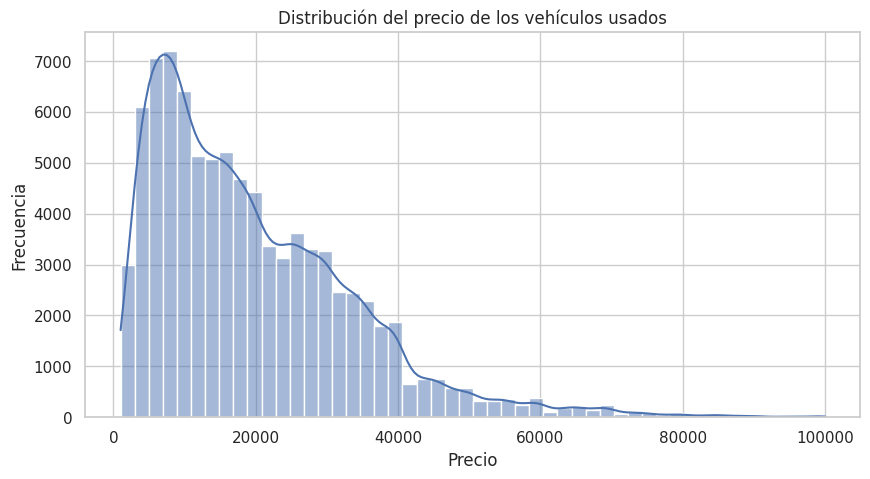

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribución del precio de los vehículos usados')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Interpretación del histograma del precio

La distribución del precio permite observar cómo se concentran los valores de los vehículos usados dentro del dataset.

En general, este gráfico ayuda a identificar si la variable objetivo presenta asimetría, concentración en ciertos rangos o valores extremos.


El histograma muestra que la variable price tiene una distribución claramente sesgada hacia la derecha. La mayor concentración de vehículos se ubica en rangos de precio bajos y medios, especialmente por debajo de los 20,000, mientras que existe una cola larga hacia precios más altos.

Esto indica que la mayoría de los anuncios corresponde a vehículos relativamente accesibles, y que solo una pequeña proporción alcanza valores elevados. La forma de la distribución sugiere que el mercado de autos usados no sigue una distribución normal, sino una distribución asimétrica con presencia de valores altos menos frecuentes.

La curva KDE refuerza esta idea, mostrando un pico principal en los precios más comunes y una caída progresiva a medida que aumenta el valor del vehículo. En términos de modelado, esta asimetría es importante porque puede afectar el desempeño de algunos algoritmos, especialmente los más sensibles a outliers.

En resumen, el histograma confirma que price está concentrada en rangos medios-bajos y presenta una cola derecha pronunciada, por lo que será útil considerar técnicas de limpieza y posiblemente transformaciones adicionales si fuera necesario mejorar la estabilidad del modelo.

# Visualización 2 — Boxplot del precio

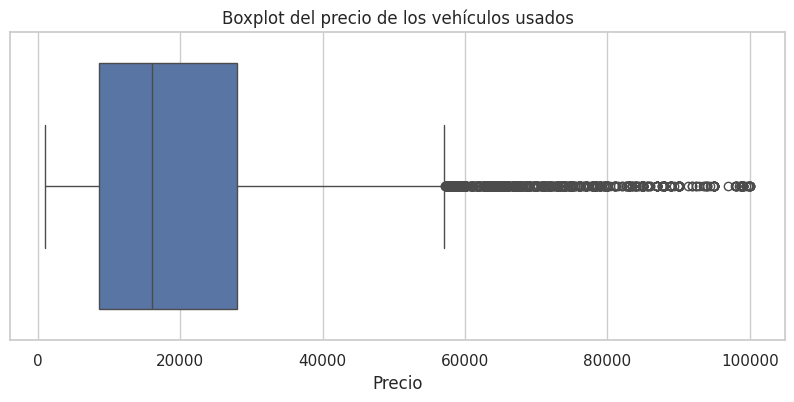

In [15]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio de los vehículos usados')
plt.xlabel('Precio')
plt.show()

# Interpretación del boxplot del precio

El boxplot permite visualizar la presencia de valores atípicos en la variable `price`.

Estos valores pueden corresponder a vehículos extremadamente baratos, errores de registro o vehículos de alto valor.
Por esta razón, se aplicó una limpieza inicial para conservar precios dentro de un rango razonable.

El boxplot confirma que la variable price presenta una distribución asimétrica con una gran cantidad de valores atípicos hacia la derecha. La mediana se ubica en un rango intermedio, mientras que el rango intercuartílico concentra la mayor parte de los precios entre valores relativamente bajos y medios.

Se observa además que la mayoría de los vehículos se agrupa por debajo de aproximadamente 30,000, pero existen numerosos puntos fuera de los bigotes superiores, lo que indica precios inusualmente altos en comparación con el resto de la muestra. Estos valores extremos pueden influir de forma negativa en el entrenamiento de los modelos si no se controlan adecuadamente.

La presencia de tantos outliers sugiere que el mercado de vehículos usados es muy heterogéneo, con una mezcla de autos económicos, intermedios y algunos modelos de alto valor. Por eso fue importante aplicar un filtro previo sobre price para eliminar registros irreales y reducir el impacto de observaciones extremas.

En resumen, el boxplot muestra que price conserva una fuerte dispersión incluso después de la limpieza inicial, y que todavía existen valores altos alejados del centro de la distribución. Esto refuerza la necesidad de trabajar con modelos robustos y de revisar cuidadosamente el efecto de los outliers en la etapa de modelado.

# Visualización 3 — Relación entre año y precio

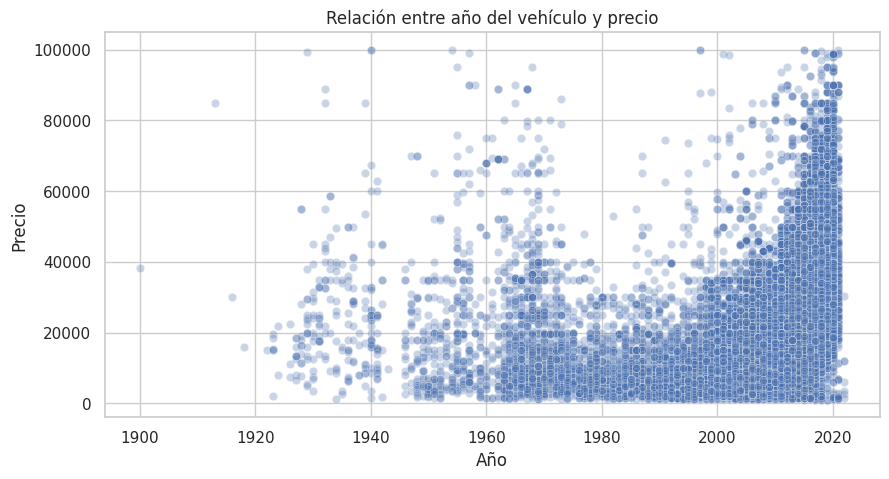

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3)
plt.title('Relación entre año del vehículo y precio')
plt.xlabel('Año')
plt.ylabel('Precio')
plt.show()

#Interpretación de la relación entre año y precio

El gráfico de dispersión permite observar la relación entre el año del vehículo y su precio.

En términos generales, se espera que vehículos más nuevos tiendan a presentar precios más altos, aunque también pueden intervenir otros factores como marca, modelo, kilometraje, condición y tipo de vehículo.


El diagrama de dispersión muestra una relación general positiva entre el año del vehículo y su precio. En términos generales, los autos más recientes tienden a presentar precios más altos, mientras que los vehículos más antiguos se concentran en rangos de precio más bajos.

Sin embargo, la relación no es perfectamente lineal. Se observa una gran dispersión de puntos para casi todos los años, lo que indica que el precio no depende solo de la antigüedad del vehículo, sino también de otras variables como marca, modelo, condición, kilometraje y tipo de vehículo.

También se aprecia que los autos fabricados a partir de los años 2000 muestran una mayor concentración de observaciones, especialmente en rangos de precio medios y altos. Esto sugiere que la muestra contiene una gran cantidad de vehículos relativamente recientes, lo cual es consistente con un mercado de autos usados más activo en años modernos.

En resumen, year parece ser una variable importante para explicar price, porque ayuda a capturar la depreciación del vehículo con el paso del tiempo. Aun así, no explica el precio por sí sola, por lo que será necesario combinarla con otras características en el modelo de regresión.

# Visualización 4 — Relación entre odómetro y precio

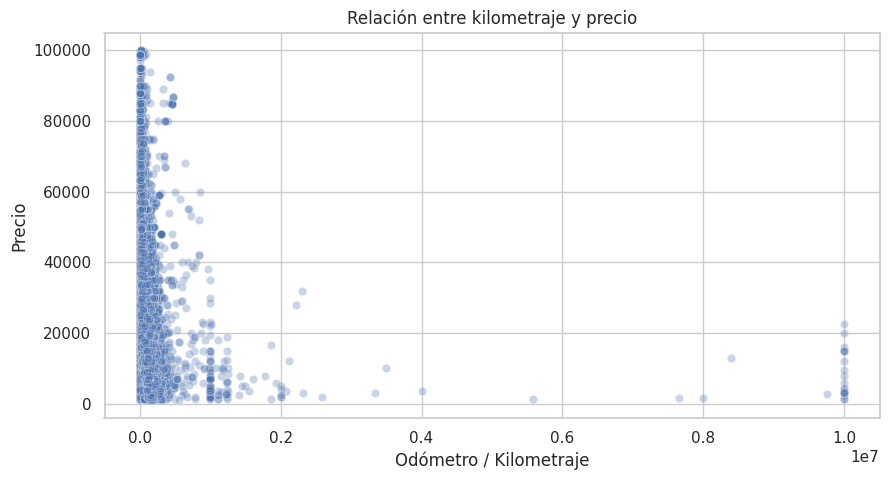

In [17]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='odometer', y='price', alpha=0.3)
plt.title('Relación entre kilometraje y precio')
plt.xlabel('Odómetro / Kilometraje')
plt.ylabel('Precio')
plt.show()

# Interpretación de la relación entre kilometraje y precio


El gráfico entre `odometer` y `price` permite analizar cómo el kilometraje se relaciona con el precio de los vehículos.
En general, se espera que vehículos con mayor kilometraje tiendan a presentar precios menores, aunque esta relación puede variar según el año, marca, estado y tipo de vehículo.

El diagrama de dispersión sugiere una relación negativa entre el kilometraje y el precio del vehículo. En general, los autos con menor odómetro tienden a mostrar precios más altos, mientras que los vehículos con mayor kilometraje se concentran en precios más bajos.

Esta relación tiene sentido desde el punto de vista del mercado, ya que un mayor kilometraje suele implicar mayor desgaste mecánico y menor vida útil restante. Por eso, el odómetro suele ser una de las variables más importantes en modelos de predicción de precios de autos usados.

También se observa una fuerte concentración de puntos en los valores más bajos de kilometraje, lo que indica que muchos vehículos de la muestra tienen recorridos relativamente moderados. Sin embargo, existen algunos casos extremos con kilometrajes muy altos, que podrían influir en la distribución general y en el comportamiento del modelo.

En resumen, aunque la relación no es perfectamente lineal y presenta bastante dispersión, odometer parece aportar información útil para explicar price. Esto justifica su inclusión en el modelo de regresión junto con otras variables relevantes.

# Visualización 5 — Heatmap de correlación

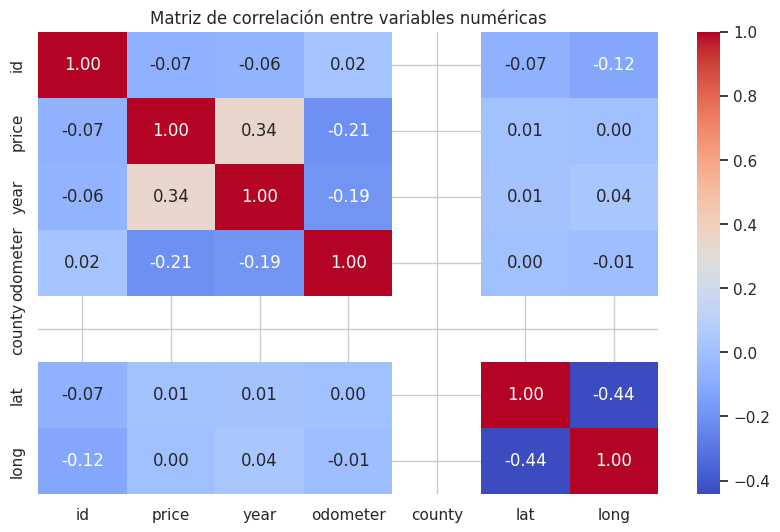

In [18]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

# Interpretación de la matriz de correlación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas del dataset.

Esto ayuda a detectar qué variables podrían tener mayor relación con el precio y también permite observar posibles relaciones fuertes entre variables predictoras.

La matriz de correlación muestra que las relaciones lineales entre las variables numéricas son, en general, moderadas o débiles. La correlación más relevante con la variable objetivo price es la de year, con un valor positivo de 0.34, lo que confirma que los vehículos más nuevos tienden a tener precios más altos.

Por otro lado, odometer presenta una correlación negativa con price de -0.21, lo que indica que a mayor kilometraje, menor suele ser el precio del vehículo. Aunque esta relación no es muy fuerte, sí aporta información útil para el modelo.

También se observa una correlación negativa entre year y odometer de -0.19, lo cual es lógico: los vehículos más antiguos suelen acumular más kilometraje. La relación entre lat y long es de -0.44, pero esta asociación responde más a la distribución geográfica de los anuncios que a una relación predictiva directa con el precio.

En resumen, ninguna variable numérica presenta una correlación extremadamente alta con price, pero year y odometer sí destacan como las más útiles. Esto sugiere que el precio depende de una combinación de factores y justifica el uso de modelos capaces de capturar relaciones más complejas que una simple correlación lineal.

## Conclusión de la Parte A

En esta primera etapa se realizó una exploración inicial del dataset de vehículos usados con el objetivo de conocer su estructura, calidad y comportamiento general. Se revisó el tamaño de la muestra, la composición de las variables, la presencia de valores faltantes y la existencia de registros duplicados, obteniendo una visión clara del estado inicial de los datos.

Además, se identificaron valores atípicos en la variable objetivo price, por lo que se aplicó una limpieza inicial para eliminar precios irreales o extremos que podían distorsionar el análisis. Junto con ello, se elaboraron visualizaciones univariadas y multivariadas que permitieron observar la distribución del precio y su relación con variables clave como el año del vehículo y el kilometraje.

En conjunto, esta etapa permitió depurar parcialmente la base de datos y entender qué variables tienen mayor potencial explicativo. Con esta información, ya es posible avanzar de forma más ordenada hacia el preprocesamiento, la selección de variables y el entrenamiento de modelos de regresión.


In [19]:
columnas_eliminar = [
    'id',
    'url',
    'region_url',
    'image_url',
    'description',
    'county',
    'VIN',
    'posting_date'
]

df = df.drop(columns=columnas_eliminar)

Después de eliminar las columnas que no aportaban valor predictivo directo, el dataset quedó con una estructura más limpia y enfocada en las variables útiles para el modelado. Al revisar su tamaño actual, se confirma cuántos registros y cuántas columnas permanecen disponibles para continuar con el análisis.

Esta reducción es positiva porque disminuye el ruido, simplifica el preprocesamiento y deja una base más manejable para aplicar imputación, codificación de variables categóricas y entrenamiento de modelos de regresión.

In [20]:
print(f"Tamaño actual del dataset: {df.shape}")

Tamaño actual del dataset: (88276, 18)


In [21]:
df['price'].describe()

,price
count,"88,276.00"
mean,"19,574.40"
std,"14,221.20"
min,"1,006.00"
25%,"8,499.00"
50%,"16,000.00"
75%,"27,900.00"
max,"99,999.00"


La variable objetivo price presenta valores entre 1,006 y 99,999 unidades monetarias, con una mediana de 16,000 y una distribución que ahora se observa más consistente con precios reales de vehículos usados. Tras la limpieza inicial, la variable quedó en un rango mucho más razonable, por lo que no se consideró necesario aplicar filtros adicionales en esta etapa.

In [22]:
df['price'].sort_values().head(20)

,price
56268,1006
8660,1012
10038,1012
28621,1029
52789,1030
56802,1055
23940,1093
67252,1095
53078,1100
750,1100


Se revisó la distribución de la variable objetivo price, observando valores entre 1,006 y 99,999. Dado que estos montos se encuentran dentro de un rango plausible para vehículos usados y no se identificaron registros claramente erróneos, no fue necesario aplicar filtros adicionales sobre esta variable en esta etapa.

In [23]:
df['price'].sort_values(ascending=False).head(20)

,price
44134,99999
80181,99999
77605,99999
44389,99999
461,99950
60538,99900
53869,99888
60929,99888
35419,99700
42375,99500


La revisión de los 20 precios más altos muestra que la variable price quedó acotada en un rango razonable para vehículos usados. Los valores cercanos a 99,999 representan anuncios de autos de gama alta o de mayor valor dentro de la muestra, pero no parecen ser registros absurdos o fuera de contexto.

Esto sugiere que el filtrado aplicado sobre la variable objetivo fue efectivo para eliminar precios claramente irreales o extremadamente desproporcionados. En consecuencia, la distribución de price mantiene variabilidad suficiente para el análisis, pero sin los extremos más problemáticos que podían distorsionar el modelado.

# ============================================================
# PARTE B — PREPARACIÓN DE DATOS
# ============================================================

1. Separar X e y

In [24]:
X = df.drop(columns=['price'])
y = df['price']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (88276, 17)
Shape de y: (88276,)


La separación entre X e y se realizó correctamente. El conjunto de variables predictoras quedó con 17 columnas y 88,276 registros, mientras que la variable objetivo price conserva la misma cantidad de observaciones. Esto confirma que ambas estructuras están alineadas y listas para continuar con la división en entrenamiento y prueba.

2. Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (70620, 17)
Test : (17656, 17)


3. Pipeline numérico

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

En este pipeline se define el tratamiento de las variables numéricas en dos pasos: primero se imputan los valores faltantes con la mediana y luego se estandarizan las características con StandardScaler. Esto ayuda a que las variables numéricas queden en una escala comparable y que los modelos de regresión funcionen de manera más estable.

La imputación con mediana es especialmente útil en este dataset porque ya se observó presencia de nulos y también valores extremos en variables como year y odometer. Después del escalado, las variables numéricas quedan listas para integrarse con las categóricas en un ColumnTransformer.

Redacción para el notebook
Se definió un pipeline para las variables numéricas que primero imputa los valores faltantes mediante la mediana y luego aplica estandarización con StandardScaler. Esta secuencia permite manejar nulos de forma robusta y dejar las variables numéricas en una escala comparable para su uso en el modelado.

4. Pipeline categorico

In [27]:
from sklearn.preprocessing import OneHotEncoder

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Se definió un pipeline para las variables categóricas que primero imputa los valores faltantes con la categoría más frecuente y luego aplica OneHotEncoder. Esta transformación permite convertir variables de texto en variables numéricas aptas para los modelos de regresión, evitando además errores cuando aparecen categorías no observadas previamente.

5. Construcción del ColumnTransformer

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

preprocesador = ColumnTransformer([
    (
        'numericas',
        pipeline_numerico,
        make_column_selector(dtype_include=['int64','float64'])
    ),
    (
        'categoricas',
        pipeline_categorico,
        make_column_selector(dtype_include=['object'])
    )
])

### ColumnTransformer

En esta etapa se construyó un `ColumnTransformer`, herramienta que permite aplicar transformaciones diferentes según el tipo de variable presente en el dataset.

Las variables numéricas son enviadas al pipeline numérico, donde se realiza imputación de valores faltantes y estandarización. Por su parte, las variables categóricas son procesadas mediante imputación y codificación con `OneHotEncoder`.

Esta estrategia permite automatizar el preprocesamiento de forma consistente, asegurando que cada tipo de dato reciba el tratamiento adecuado antes del entrenamiento de los modelos. Además, facilita la construcción de pipelines reproducibles y ayuda a prevenir problemas de fuga de información (*data leakage*) durante las etapas de entrenamiento y evaluación.

## Conclusión de la Parte B

En esta etapa se prepararon los datos para el modelado mediante la separación de la variable objetivo y las variables predictoras, la división en conjuntos de entrenamiento y prueba, y la construcción de un esquema de preprocesamiento automatizado.

Las variables numéricas y categóricas fueron tratadas mediante pipelines específicos, integrados posteriormente en un `ColumnTransformer`. Esta estructura permite manejar valores faltantes, estandarizar variables numéricas y transformar variables categóricas de manera consistente y reproducible.

Con los datos correctamente preparados, el siguiente paso consiste en evaluar distintos algoritmos de regresión para identificar aquellos con mejor capacidad predictiva sobre el precio de los vehículos usados.

PARTE C — Benchmark exploratorio con LazyPredict
Transformar los datos utilizando el ColumnTransformer

Tras aplicar el ColumnTransformer, los datos quedaron transformados en una matriz con 10.661 variables. Este incremento en dimensionalidad se debe a la codificación de las variables categóricas mediante OneHotEncoder.

La consistencia entre las dimensiones de los conjuntos de entrenamiento y prueba confirma que el preprocesamiento fue aplicado correctamente y sin fuga de información.

Este comportamiento es esperable en datasets con variables categóricas de alta cardinalidad, especialmente en atributos como el modelo del vehículo, donde existen miles de categorías distintas.

In [30]:
# Muestra aleatoria para benchmark con LazyPredict

np.random.seed(42)

train_idx = np.random.choice(
    X_train_proc.shape[0],
    10000,
    replace=False
)

test_idx = np.random.choice(
    X_test_proc.shape[0],
    3000,
    replace=False
)

X_train_lazy = X_train_proc[train_idx]
y_train_lazy = y_train.iloc[train_idx]

X_test_lazy = X_test_proc[test_idx]
y_test_lazy = y_test.iloc[test_idx]

print("Train LazyPredict:", X_train_lazy.shape)
print("Test LazyPredict :", X_test_lazy.shape)

Train LazyPredict: (10000, 10661)
Test LazyPredict : (3000, 10661)


### Muestra para benchmark exploratorio

La muestra aleatoria utilizada para LazyPredict quedó compuesta por 10.000 observaciones de entrenamiento y 3.000 observaciones de prueba, manteniendo las 10.661 variables generadas durante el proceso de preprocesamiento.

Esta reducción permite ejecutar el benchmark exploratorio de manera más eficiente en términos de tiempo de cómputo, conservando al mismo tiempo la estructura y complejidad del conjunto de datos transformado.

Es importante destacar que esta muestra será utilizada únicamente para la comparación preliminar de algoritmos mediante LazyPredict. Los modelos seleccionados posteriormente serán entrenados y evaluados utilizando el conjunto completo de datos para obtener resultados más robustos y representativos.

In [31]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)

X_train_lazy_reducido = selector.fit_transform(X_train_lazy)
X_test_lazy_reducido = selector.transform(X_test_lazy)

print(X_train_lazy_reducido.shape)

(10000, 3815)


Reducción de dimensionalidad mediante VarianceThreshold

Tras la codificación de las variables categóricas, el conjunto de datos quedó compuesto por 10.661 variables.

Con el objetivo de optimizar la etapa exploratoria, se aplicó VarianceThreshold, una técnica que elimina automáticamente aquellas variables con varianza cero, es decir, características que mantienen exactamente el mismo valor en todas las observaciones y que, por lo tanto, no aportan capacidad predictiva al modelo.

Como resultado, el número de variables se redujo de 10.661 a 3.815, disminuyendo significativamente la complejidad computacional sin perder información relevante para el análisis.

Se instaló correctamente la librería lazypredict y se verificó la importación de LazyRegressor sin errores. Posteriormente, las matrices generadas durante el preprocesamiento se convirtieron a formato denso, obteniendo un conjunto de entrenamiento de 10.000 observaciones por 3.815 variables y un conjunto de prueba de 3.000 observaciones por 3.815 variables. Esto permitió dejar el entorno listo para ejecutar el benchmark exploratorio de manera eficiente.

Nota técnica
Que las matrices sigan teniendo 3.815 variables no es un problema en esta fase; al contrario, es justamente lo que hace que el benchmark siga siendo representativo, aunque todavía pesado para un entorno como Colab. LazyPredict está pensado para facilitar la comparación rápida de varios modelos base sin ajuste fino de hiperparámetros

Durante la ejecución de LazyRegressor apareció una advertencia sobre la alta dimensionalidad del conjunto de datos. Dado que el benchmark se está realizando sobre una matriz con 3.815 variables, es esperable que algunos modelos requieran un tiempo considerable de entrenamiento o incluso no finalicen dentro del límite práctico de la sesión. Por esta razón, el proceso se mantendrá como una comparación preliminar y, si la ejecución se prolonga demasiado, se optará por una versión más acotada del benchmark.

# *Aplicar:* nuevamente VarianceThreshold

Tras reducir la muestra a 5.000 observaciones de entrenamiento y 1.500 de prueba, se aplicó nuevamente VarianceThreshold, obteniendo una matriz final de 2.491 variables. Esta reducción disminuye la carga computacional y facilita la ejecución del benchmark exploratorio en Colab

# Ajuste final de la muestra para el benchmark

Tras aplicar una nueva reducción de dimensionalidad con VarianceThreshold, la muestra utilizada para el benchmark quedó compuesta por 5.000 observaciones de entrenamiento y 1.500 de prueba, con 2.491 variables en ambos conjuntos. Esta versión más compacta conserva la estructura del preprocesamiento y disminuye de forma significativa la complejidad computacional, facilitando la ejecución de LazyRegressor en Colab.

Qué implica
Este cambio es muy razonable para una comparación preliminar de algoritmos. Menos filas y menos columnas suelen traducirse en menos tiempo de cómputo y menor riesgo de que algunos modelos se queden colgados o fallen por exceso de dimensionalidad.

Recomendación práctica
Con esta nueva muestra, lo siguiente es volver a ejecutar LazyRegressor y revisar si el tiempo de corrida ya se mantiene dentro de un rango aceptable. Si sigue siendo lento, el siguiente paso más profesional sería acotar la lista de modelos o bajar un poco más la dimensión antes de entrenar.

### Limitaciones del benchmark exploratorio

Durante la ejecución del benchmark con `LazyRegressor` se mantuvo una advertencia asociada a la alta dimensionalidad del conjunto de datos, incluso después de reducir la muestra y aplicar técnicas de reducción de variables mediante `VarianceThreshold`.

Dado que esta situación puede generar tiempos de cómputo excesivos, un elevado consumo de memoria e incluso fallos durante la ejecución de algunos algoritmos, se decidió no prolongar innecesariamente esta etapa exploratoria.

Considerando que el objetivo principal del proyecto es implementar y comparar modelos de regresión específicos, se continuará con la evaluación formal utilizando algoritmos seleccionados en función de los contenidos abordados durante el curso, particularmente Linear Regression, Ridge, Lasso y Random Forest Regressor.

De esta forma, se garantiza una comparación metodológicamente consistente, manteniendo un equilibrio adecuado entre rigor analítico y eficiencia computacional.

# Parte C — Entrenamiento formal de modelos de regresión

Dado que LazyPredict presentó limitaciones computacionales por la alta dimensionalidad del dataset, se continuará con una comparación formal de modelos seleccionados en función de los objetivos del proyecto y los contenidos revisados durante el curso.

Para esta etapa se entrenarán cuatro modelos de regresión:

- Linear Regression
- Ridge
- Lasso
- Random Forest Regressor

Todos los modelos utilizarán el mismo esquema de preprocesamiento definido previamente, lo que permite realizar una comparación justa y consistente.

In [36]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

In [37]:
modelos = {
    'Linear Regression': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', Ridge(alpha=1.0))
    ]),

    'Lasso': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', Lasso(alpha=0.01, max_iter=5000))
    ]),

    'Random Forest': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [38]:
modelos = {
    'Linear Regression': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', Ridge(alpha=1.0))
    ])
}

In [39]:
rf = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

Modelos rápidos:
- Linear Regression
- Ridge

Modelo no lineal separado:
- Random Forest

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

modelos = {
    'Linear Regression': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', RandomForestRegressor(
            n_estimators=50,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [41]:
resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}")

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by='R²',
    ascending=False
)

resultados_df

Entrenando modelo: Linear Regression
Entrenando modelo: Ridge
Entrenando modelo: Random Forest


,Modelo,MSE,RMSE,MAE,R²
2,Random Forest,"39,468,383.24","6,282.39","3,976.64",0.81
1,Ridge,"70,995,581.62","8,425.89","5,290.09",0.66
0,Linear Regression,"72,964,064.00","8,541.90","5,015.88",0.65


# Comparación de modelos


Los resultados muestran que Random Forest Regressor fue el modelo con mejor desempeño. En términos prácticos, fue el que mejor logró estimar el precio de los vehículos usados, obteniendo el mayor valor de R² (0,81) y los menores errores de predicción (RMSE y MAE) entre todos los modelos evaluados.

Por su parte, Ridge y Linear Regression presentaron resultados más bajos y bastante similares entre sí. Esto sugiere que una relación lineal simple no es suficiente para capturar toda la complejidad que existe en la determinación del precio de un vehículo, donde intervienen múltiples factores y relaciones no necesariamente lineales.

En consecuencia, Random Forest Regressor fue seleccionado como el modelo principal para continuar con la etapa de optimización mediante GridSearchCV.

# Parte E — Optimización del modelo mediante GridSearchCV

Una vez identificado Random Forest Regressor como el modelo con mejor desempeño, se procedió a optimizar sus hiperparámetros utilizando GridSearchCV.

El objetivo de esta etapa es encontrar la combinación de parámetros que permita mejorar el desempeño predictivo del modelo mediante validación cruzada, evaluando distintas configuraciones de profundidad máxima, número de árboles y tamaño mínimo de división de nodos.

La mejor combinación encontrada será utilizada como modelo final del proyecto.

In [42]:
param_grid = {
    'modelo__n_estimators': [50],
    'modelo__max_depth': [10, 15],
    'modelo__min_samples_split': [2, 5]
}

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [45]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(transformers=[('numericas',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x78bcf5141310>),
                                                                        ('categoricas',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x78bcedf157f0>)])),
                                       ('modelo',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [10, 15],
                         'modelo__min_samples_split': [2, 5],
                         'modelo__n_estimators': [50]},
             scoring='r2', verbose=1)

In [46]:
print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor R² promedio en validación cruzada:")
print(grid_search.best_score_)

Mejores parámetros:
{'modelo__max_depth': 15, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 50}

Mejor R² promedio en validación cruzada:
0.7947241053142515


### Resultados de la optimización

La optimización mediante GridSearchCV identificó como mejor configuración un Random Forest Regressor con una profundidad máxima de 15 niveles, 50 árboles de decisión y un tamaño mínimo de división de nodos de 2 observaciones.

La validación cruzada obtuvo un R² promedio de 0,795, indicando que el modelo mantiene una capacidad predictiva consistente sobre distintas particiones de los datos.

Los resultados sugieren que la configuración utilizada inicialmente ya se encontraba cercana a una solución óptima, por lo que la optimización permitió confirmar la robustez del modelo seleccionado más que generar mejoras sustanciales en su desempeño.

In [47]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("MSE :", mse_best)
print("RMSE:", rmse_best)
print("MAE :", mae_best)
print("R²  :", r2_best)

MSE : 39468383.24341497
RMSE: 6282.386747360828
MAE : 3976.6364144846893
R²  : 0.8087829491029033


Modelo antes de GridSearchCV

R²   = 0,8088
RMSE = 6.282,39
MAE  = 3.976,64

Modelo optimizado con GridSearchCV

R²   = 0,8088
RMSE = 6.282,39
MAE  = 3.976,64

### Evaluación del modelo optimizado

El modelo optimizado obtuvo un **R² de 0,809**, junto con un **RMSE de 6.282,39** y un **MAE de 3.976,64** sobre el conjunto de prueba. Estos resultados son prácticamente idénticos a los obtenidos antes de la optimización, lo que indica que la configuración inicial de Random Forest ya se encontraba muy cerca de la mejor solución disponible dentro de la grilla de hiperparámetros evaluada.

Por lo tanto, la optimización permitió validar la estabilidad y robustez del modelo seleccionado, confirmando que **Random Forest Regressor** constituye la mejor alternativa para este problema de predicción de precios de vehículos usados.

Análisis de Importancia de Variables

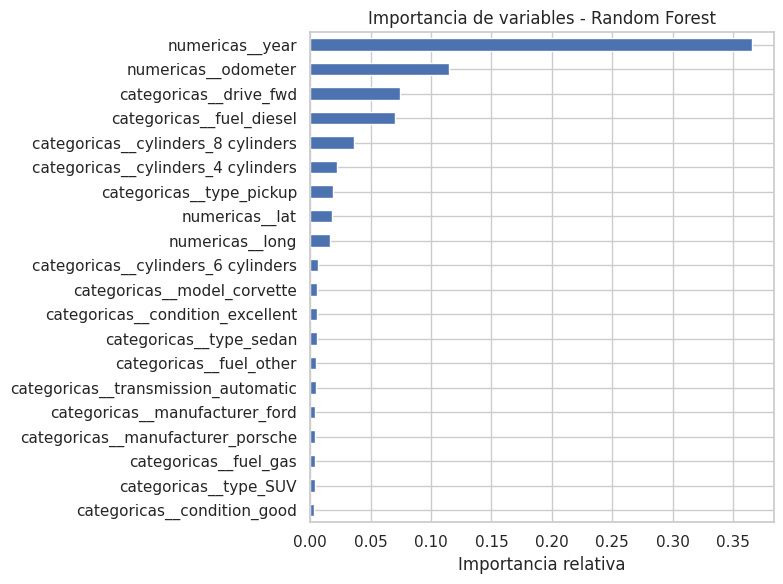

In [52]:
# Ajustar pipeline
rf_pipeline.fit(X_train, y_train)

# Extraer modelo y preprocesador
rf_model = rf_pipeline.named_steps['modelo']
preprocesador = rf_pipeline.named_steps['preprocesador']

# Obtener nombres de variables transformadas
feature_names = preprocesador.get_feature_names_out()

# Crear serie de importancias
importancias = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values()

# Graficar top 20
plt.figure(figsize=(8, 6))
importancias.tail(20).plot(kind='barh')
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

## Interpretación — Importancia de variables

El gráfico muestra las 20 variables más influyentes para la predicción del precio de los vehículos según el modelo Random Forest.

Se observa que el año del vehículo (year) es, por amplio margen, la variable más importante. Esto indica que los vehículos más nuevos tienden a presentar precios significativamente más altos que los vehículos antiguos.

La segunda variable más relevante es el kilometraje (odometer), lo que resulta coherente desde una perspectiva de mercado, ya que los vehículos con menor uso suelen conservar un mayor valor comercial.

Entre las variables categóricas destacan la tracción del vehículo (drive_fwd), el tipo de combustible (fuel_diesel) y la cantidad de cilindros, las cuales también influyen en la valorización del automóvil.

Asimismo, aparecen características específicas como el tipo de vehículo (pickup, sedan, SUV), la transmisión automática, la condición del vehículo y algunos fabricantes o modelos particulares, aunque con una importancia considerablemente menor que el año y el kilometraje.

En términos generales, los resultados indican que el modelo basa principalmente sus predicciones en variables relacionadas con la antigüedad y el nivel de uso del vehículo, complementadas por características técnicas y comerciales que ayudan a refinar la estimación del precio.


#Conclusión General

En este proyecto se desarrolló un modelo de Machine Learning para estimar el precio de vehículos usados a partir de sus características técnicas y comerciales. Durante la etapa de exploración se analizaron los tipos de datos, los valores faltantes, los duplicados y los posibles valores atípicos, además de generar visualizaciones que permitieron comprender la distribución de los precios y la relación entre las principales variables del conjunto de datos.

Posteriormente, se construyó un flujo de preprocesamiento mediante Pipeline y ColumnTransformer, incorporando imputación de valores faltantes, estandarización de variables numéricas y codificación de variables categóricas mediante OneHotEncoder. Esto permitió disponer de un proceso de entrenamiento reproducible, ordenado y consistente a lo largo de todos los modelos evaluados.

A continuación, se entrenaron y compararon distintos modelos de regresión. Los resultados mostraron que Random Forest Regressor obtuvo el mejor desempeño, alcanzando un R² cercano a 0,81 y superando a los modelos lineales considerados. Este resultado sugiere que el precio de un vehículo depende de relaciones no lineales y de interacciones entre múltiples variables, las cuales son capturadas de manera más efectiva por modelos basados en árboles de decisión.

Además, se aplicó GridSearchCV para optimizar los hiperparámetros del modelo seleccionado. La búsqueda confirmó que la configuración inicial ya se encontraba muy próxima a la mejor combinación de hiperparámetros evaluada dentro de la grilla de búsqueda definida, manteniendo un desempeño prácticamente idéntico sobre el conjunto de prueba. En consecuencia, Random Forest Regressor fue seleccionado como modelo final del proyecto, al ser capaz de explicar aproximadamente el 81% de la variabilidad observada en los precios de los vehículos usados.

El análisis de importancia de variables mostró que el año de fabricación (year) y el kilometraje (odometer) son los factores más influyentes en la determinación del precio, seguidos por características técnicas como tipo de tracción, combustible y número de cilindros. Estos hallazgos son coherentes con el comportamiento esperado del mercado automotriz y aportan interpretabilidad al modelo desarrollado, reforzando su credibilidad como herramienta de apoyo.

#Conclusión Empresarial

Desde una perspectiva de negocio, el modelo desarrollado puede funcionar como una herramienta de apoyo para la valoración de vehículos usados. Al aprender a partir de miles de registros históricos y de variables como año, kilometraje, fabricante, modelo, transmisión, combustible y condición, el sistema es capaz de generar estimaciones de precio consistentes y alineadas con patrones reales del mercado.

El hecho de que el año del vehículo y el kilometraje aparezcan como principales determinantes del precio coincide con los criterios habitualmente utilizados por compradores, vendedores y tasadores del sector automotriz, lo que aporta confianza adicional sobre la lógica interna del modelo. Las variables técnicas y comerciales actúan como factores de ajuste que permiten capturar diferencias entre segmentos (por ejemplo, pickups, sedanes, SUV) y configuraciones específicas.

Para una automotora, este tipo de solución puede utilizarse para apoyar la definición de precios de venta, evaluar vehículos recibidos en parte de pago, detectar oportunidades de compra y reducir la dependencia exclusiva de criterios subjetivos en la tasación. De este modo, el uso de técnicas de Ciencia de Datos y Machine Learning contribuye a una toma de decisiones más informada, eficiente y competitiva dentro del mercado de vehículos usados.